In [1]:
import sys, platform
print("Python executable:", sys.executable)
print("Python version   :", sys.version.split()[0])
print("OS               :", platform.platform())

try:
    import torch
    print("PyTorch          :", torch.__version__)
    print("CUDA available   :", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU              :", torch.cuda.get_device_name(0))
except ImportError:
    print("PyTorch          : not installed (not required for audit)")


Python executable: /home/adminbum/ntqai/.venv/bin/python
Python version   : 3.12.3
OS               : Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
PyTorch          : not installed (not required for audit)


In [2]:
from pathlib import Path
import hashlib, warnings
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Librosa:", librosa.__version__)
print("SoundFile:", sf.__version__)


NumPy: 2.5.3
Pandas: 3.0.6
Librosa: 1.0.0
SoundFile: 0.14.0


/home/adminbum/ntqai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATASET_PATH = Path("/mnt/d/Data/VNTM3")
REPORT_DIR = DATASET_PATH / "_audit"
AUDIO_EXTENSIONS = {".wav", ".mp3", ".flac", ".ogg", ".m4a", ".aac"}

print("Dataset:", DATASET_PATH)
print("Exists :", DATASET_PATH.exists())

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy {DATASET_PATH}")

REPORT_DIR.mkdir(exist_ok=True)


Dataset: /mnt/d/Data/VNTM3
Exists : True


In [4]:
class_dirs = sorted([
    p for p in DATASET_PATH.iterdir()
    if p.is_dir() and not p.name.startswith("_") and not p.name.startswith(".")
])

for p in class_dirs:
    n = sum(1 for f in p.rglob("*")
            if f.is_file() and f.suffix.lower() in AUDIO_EXTENSIONS)
    print(f"{p.name:20s}: {n:,}")

audio_files = sorted([
    p for p in DATASET_PATH.rglob("*")
    if p.is_file()
    and p.suffix.lower() in AUDIO_EXTENSIONS
    and "_audit" not in p.parts
])

print("\nTotal audio:", f"{len(audio_files):,}")
if not audio_files:
    raise RuntimeError("Không tìm thấy audio.")


cailuong            : 500
catru               : 499
chauvan             : 500
cheo                : 500
hatxam              : 500

Total audio: 2,499


In [5]:
records = []

for path in tqdm(audio_files, desc="Auditing audio"):
    label = path.parent.name
    base = {
        "label": label,
        "filename": path.name,
        "relative_path": str(path.relative_to(DATASET_PATH)),
        "path": str(path),
    }
    try:
        info = sf.info(str(path))
        y, _ = librosa.load(str(path), sr=None, mono=True)

        if len(y):
            peak = float(np.max(np.abs(y)))
            rms = float(np.sqrt(np.mean(np.square(y), dtype=np.float64)))
        else:
            peak, rms = 0.0, 0.0

        records.append({
            **base,
            "duration_sec": float(info.duration),
            "sample_rate": int(info.samplerate),
            "channels": int(info.channels),
            "frames": int(info.frames),
            "peak": peak,
            "rms": rms,
            "near_silent": bool(rms < 0.001),
            "status": "OK",
            "error": "",
        })
    except Exception as e:
        records.append({
            **base,
            "duration_sec": np.nan,
            "sample_rate": np.nan,
            "channels": np.nan,
            "frames": np.nan,
            "peak": np.nan,
            "rms": np.nan,
            "near_silent": np.nan,
            "status": "ERROR",
            "error": repr(e),
        })

audit_df = pd.DataFrame(records)
display(audit_df.head())
print("Rows:", len(audit_df))


Auditing audio: 100%|██████████| 2499/2499 [01:03<00:00, 39.09it/s]


,label,filename,relative_path,path,duration_sec,sample_rate,channels,frames,peak,rms,near_silent,status,error
0,cailuong,CaiLuong.000.wav,cailuong/CaiLuong.000.wav,/mnt/d/Data/VNTM3/cailuong/CaiLuong.000.wav,30.0,22050,1,661500,0.605774,0.078600,False,OK,
1,cailuong,CaiLuong.001.wav,cailuong/CaiLuong.001.wav,/mnt/d/Data/VNTM3/cailuong/CaiLuong.001.wav,30.0,22050,1,661500,0.814911,0.143234,False,OK,
2,cailuong,CaiLuong.002.wav,cailuong/CaiLuong.002.wav,/mnt/d/Data/VNTM3/cailuong/CaiLuong.002.wav,30.0,22050,1,661500,0.888245,0.116666,False,OK,
3,cailuong,CaiLuong.003.wav,cailuong/CaiLuong.003.wav,/mnt/d/Data/VNTM3/cailuong/CaiLuong.003.wav,30.0,22050,1,661500,0.995361,0.156985,False,OK,
4,cailuong,CaiLuong.004.wav,cailuong/CaiLuong.004.wav,/mnt/d/Data/VNTM3/cailuong/CaiLuong.004.wav,30.0,22050,1,661500,0.993103,0.144268,False,OK,


Rows: 2499


In [6]:
print("FILES PER CLASS")
display(audit_df.groupby("label").size().rename("files").reset_index())

print("DURATION PER CLASS")
display(audit_df.groupby("label")["duration_sec"]
        .agg(["count","mean","std","min","median","max"]).round(3))

print("SAMPLE RATES")
display(audit_df["sample_rate"].value_counts(dropna=False)
        .rename_axis("sample_rate").reset_index(name="files"))

print("CHANNELS")
display(audit_df["channels"].value_counts(dropna=False)
        .rename_axis("channels").reset_index(name="files"))


FILES PER CLASS


,label,files
0,cailuong,500
1,catru,499
2,chauvan,500
3,cheo,500
4,hatxam,500


DURATION PER CLASS


,count,mean,std,min,median,max
label,,,,,,
cailuong,500,30.000,0.000,30.000,30.0,30.0
catru,499,29.800,2.074,2.019,30.0,30.0
chauvan,500,29.983,0.270,25.728,30.0,30.0
cheo,500,30.000,0.000,30.000,30.0,30.0
hatxam,500,30.000,0.000,30.000,30.0,30.0


SAMPLE RATES


,sample_rate,files
0,22050,2496
1,44100,3


CHANNELS


,channels,files
0,1,2499


In [7]:
duration_outliers = audit_df[
    (audit_df["status"]=="OK") &
    ((audit_df["duration_sec"] < 29.0) | (audit_df["duration_sec"] > 31.0))
].copy()

silent_df = audit_df[
    (audit_df["status"]=="OK") & (audit_df["near_silent"]==True)
].copy()

error_df = audit_df[audit_df["status"]!="OK"].copy()

print("Duration outside 29–31s:", len(duration_outliers))
print("Near-silent             :", len(silent_df))
print("Unreadable/error        :", len(error_df))

if len(duration_outliers):
    display(duration_outliers[["label","filename","duration_sec","sample_rate","channels"]])
if len(silent_df):
    display(silent_df[["label","filename","rms","peak"]])
if len(error_df):
    display(error_df[["label","filename","error"]])


Duration outside 29–31s: 9
Near-silent             : 0
Unreadable/error        : 0


,label,filename,duration_sec,sample_rate,channels
722,catru,Catru.223.wav,12.329252,22050,1
869,catru,Catru.370.wav,18.172517,22050,1
870,catru,Catru.371.wav,18.172517,22050,1
975,catru,Catru.476.wav,28.683537,22050,1
976,catru,Catru.477.wav,28.683537,22050,1
989,catru,Catru.490.wav,2.019048,22050,1
990,catru,Catru.491.wav,2.019048,22050,1
1357,chauvan,Chauvan.358.wav,25.728435,22050,1
1358,chauvan,Chauvan.359.wav,25.728435,22050,1


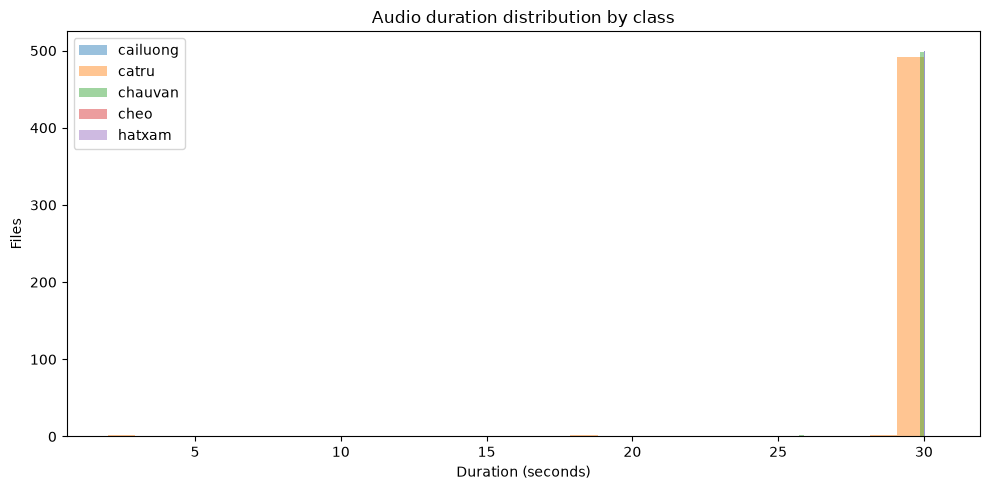

In [8]:
ok_df = audit_df[audit_df["status"]=="OK"]

plt.figure(figsize=(10,5))
for label, part in ok_df.groupby("label"):
    plt.hist(part["duration_sec"], bins=30, alpha=0.45, label=label)
plt.xlabel("Duration (seconds)")
plt.ylabel("Files")
plt.title("Audio duration distribution by class")
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
def sha256_file(path, chunk_size=1024*1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

hash_map = {}
for path in tqdm(audio_files, desc="SHA-256"):
    try:
        hash_map[str(path)] = sha256_file(path)
    except Exception:
        hash_map[str(path)] = None

audit_df["sha256"] = audit_df["path"].map(hash_map)

duplicate_df = audit_df[
    audit_df["sha256"].notna() &
    audit_df["sha256"].duplicated(keep=False)
].sort_values(["sha256","label","filename"])

print("Files involved in exact duplicates:", len(duplicate_df))
print("Exact duplicate groups:", duplicate_df["sha256"].nunique())

if len(duplicate_df):
    display(duplicate_df[["label","filename","relative_path","sha256"]])
else:
    print("No exact duplicates found.")


SHA-256: 100%|██████████| 2499/2499 [00:13<00:00, 183.72it/s]

Files involved in exact duplicates: 8
Exact duplicate groups: 4


,label,filename,relative_path,sha256
989,catru,Catru.490.wav,catru/Catru.490.wav,2d1762e6ceb5c16fb4c4f83ec23bc71a56e1862d3a19a9...
990,catru,Catru.491.wav,catru/Catru.491.wav,2d1762e6ceb5c16fb4c4f83ec23bc71a56e1862d3a19a9...
869,catru,Catru.370.wav,catru/Catru.370.wav,475e22b7a39ef040f10340b3896759fffda026fb777701...
870,catru,Catru.371.wav,catru/Catru.371.wav,475e22b7a39ef040f10340b3896759fffda026fb777701...
1357,chauvan,Chauvan.358.wav,chauvan/Chauvan.358.wav,583bef4ce0d3ef2817d5012f7bfa319928fc38833fe1aa...
1358,chauvan,Chauvan.359.wav,chauvan/Chauvan.359.wav,583bef4ce0d3ef2817d5012f7bfa319928fc38833fe1aa...
975,catru,Catru.476.wav,catru/Catru.476.wav,b452b0e6b7ed4d155b7ca238f217a5328be7aa87ea221a...
976,catru,Catru.477.wav,catru/Catru.477.wav,b452b0e6b7ed4d155b7ca238f217a5328be7aa87ea221a...


In [10]:
files_to_save = {
    "audio_audit.csv": audit_df,
    "duration_outliers.csv": duration_outliers,
    "near_silent.csv": silent_df,
    "audio_errors.csv": error_df,
    "exact_duplicates.csv": duplicate_df,
}

for name, frame in files_to_save.items():
    out = REPORT_DIR / name
    frame.to_csv(out, index=False, encoding="utf-8-sig")
    print("Saved:", out)


Saved: /mnt/d/Data/VNTM3/_audit/audio_audit.csv
Saved: /mnt/d/Data/VNTM3/_audit/duration_outliers.csv
Saved: /mnt/d/Data/VNTM3/_audit/near_silent.csv
Saved: /mnt/d/Data/VNTM3/_audit/audio_errors.csv
Saved: /mnt/d/Data/VNTM3/_audit/exact_duplicates.csv


In [11]:
summary = {
    "total_audio": len(audit_df),
    "classes": audit_df["label"].nunique(),
    "ok_files": int((audit_df["status"]=="OK").sum()),
    "error_files": len(error_df),
    "near_silent_files": len(silent_df),
    "duration_outliers": len(duration_outliers),
    "exact_duplicate_files": len(duplicate_df),
    "exact_duplicate_groups": int(duplicate_df["sha256"].nunique()) if len(duplicate_df) else 0,
}
for k,v in summary.items():
    print(f"{k:28s}: {v}")
print("\nAudit complete. Raw audio was not modified.")


total_audio                 : 2499
classes                     : 5
ok_files                    : 2499
error_files                 : 0
near_silent_files           : 0
duration_outliers           : 9
exact_duplicate_files       : 8
exact_duplicate_groups      : 4

Audit complete. Raw audio was not modified.
